## Clustering Algorithms

In this tutorial, we will explore some common clustering methods, including K-Means clustering, DBSCAN, and Gaussian Mixture Models. 

We'll apply these clustering algorithms to a data set of aerosol observations from a laboratory study. Aerosols are any types of small particulate matter that is suspended in the atmosphere. They play an important in the climate because they directly scatter and absorb sunlight. Aerosols also play an important role in cloud formation, since ice or liquid droplets that form in the atmosphere typically require some type of solid aerosol particle to act as an ice nuclei or cloud condensation nuclei. Finally, aerosols are important for air quality; small particulate matter <2.5 um (PM2.5) has significant impacts on human health.

The aerosol observations that we will look at here comes from a specialized type of instrument called the Single Particle Soot Photometer (SP2), which can be used to measure aerosols that strongly absorb sunlight, such as black carbon and iron oxide aerosols from combustion sources. It is used in airborne and ground-based field studies to measure the atmospheric mass loadings of absorbing aerosols.

The data set includes 7 different classes of aerosols that can be detected by the SP2. 

These data sets come from the study:

[1] K.D. Lamb. "Classification of iron oxide aerosols with a single particle soot photometer using supervised machine learning." *Atmospheric Measurement Techniques*, 12, 3885‑3906, 2019.

In [45]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

## Load the data

In [37]:
path = "/Users/karalamb/Columbia/Projects/SP2"

The data is already split in training, validation, and test data sets. For this analysis, we will just look at the training data set. 

In [40]:
X_train = np.load(os.path.join(path,"Lab_X_train.npy"))
y_train = np.load(os.path.join(path,"Lab_y_train.npy"))

In [43]:
print(X_train.shape)

(140082, 400, 4)


The first dimension in X_train is the sample number, and each observed aerosol has a 400 point time series from 4 different detectors. We can visualize an example of the signal associated with a single aerosol particle here:

In [ ]:
plt.plo

In [44]:
print(np.unique(y_train))

[0. 1. 2. 3. 4. 5. 6.]


The data set includes 7 different classes of aerosols. 

In [6]:
path = "/Users/karalamb/Columbia/Projects/ML4Climate2025/ML4Climate2025/lectures_ML/SupervisedML"

In [8]:
data = pd.read_csv(os.path.join(path,"FPA_FOD_west_cleaned.csv"))

In [9]:
data.head()

,DISCOVERY_DOY,FIRE_YEAR,STATE,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,pr,tmmn,...,GHM,NDVI-1day,NPL,Popo_1km,RPL_THEMES,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,Distance2road
0,1,2007,CA,6053.0,Misuse of fire by a minor,1625,257,286.0,0.0,276.500000,...,0.42,0.00,1.0,1.1494,0.055,0.027,0.245,0.039,0.203,43.0
1,1,2007,CA,6019.0,Arson/incendiarism,1819,383,290.0,0.0,273.200012,...,0.35,0.50,1.0,0.1652,0.525,0.719,0.499,0.302,0.405,40.2
2,1,2007,CA,6089.0,Misuse of fire by a minor,2293,985,290.0,0.0,275.100006,...,0.16,0.42,1.0,0.0504,0.476,0.635,0.516,0.002,0.581,43.8
3,1,2007,CA,6089.0,Misuse of fire by a minor,2293,985,290.0,0.0,275.100006,...,0.16,0.42,1.0,0.0504,0.476,0.635,0.516,0.002,0.581,43.8
4,1,2007,CA,6079.0,Debris and open burning,2423,102,289.0,0.0,271.299988,...,0.18,0.16,1.0,0.0718,0.295,0.309,0.321,0.105,0.313,41.0


In [10]:
data.columns

Index(['DISCOVERY_DOY', 'FIRE_YEAR', 'STATE', 'FIPS_CODE',
       'NWCG_GENERAL_CAUSE', 'Annual_etr', 'Annual_precipitation',
       'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd',
       'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
       'TPI_1km', 'EVC', 'Evacuation', 'SDI', 'FRG', 'No_FireStation_5.0km',
       'Mang_Name', 'GAP_Sts', 'GACC_PL', 'GDP', 'GHM', 'NDVI-1day', 'NPL',
       'Popo_1km', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3',
       'RPL_THEME4', 'Distance2road'],
      dtype='object')

In [11]:
firecauses = data['NWCG_GENERAL_CAUSE'].value_counts()
print(firecauses)

NWCG_GENERAL_CAUSE
Natural                                       168349
Missing data/not specified/undetermined       150427
Equipment and vehicle use                      48994
Debris and open burning                        40516
Recreation and ceremony                        38665
Arson/incendiarism                             28090
Smoking                                        13547
Misuse of fire by a minor                      11523
Power generation/transmission/distribution      6469
Fireworks                                       6373
Railroad operations and maintenance             3074
Other causes                                    2068
Firearms and explosives use                     1594
Name: count, dtype: int64


In [14]:
## Deal with some bad data 
data.loc[data["GHM"]<0.0,"GHM"] = np.nan
data.loc[data["SDI"]<0.0,"SDI"] = np.nan
data['FRG'] = data['FRG'].replace(-9999,np.nan)
data["RPL_THEMES"] = data["RPL_THEMES"].replace(-999.0,np.nan)
data["RPL_THEME1"] = data["RPL_THEME1"].replace(-999.0,np.nan)
data["RPL_THEME2"] = data["RPL_THEME2"].replace(-999.0,np.nan)
data["RPL_THEME3"] = data["RPL_THEME3"].replace(-999.0,np.nan)
data["RPL_THEME4"] = data["RPL_THEME4"].replace(-999.0,np.nan)

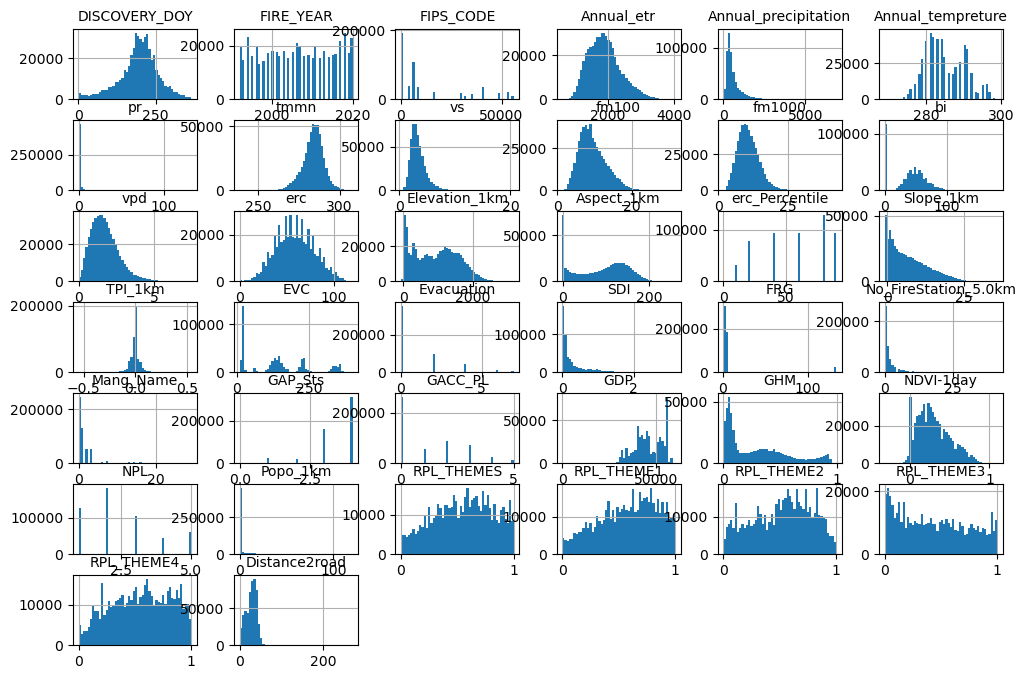

In [15]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

data.hist(bins=50, figsize=(12, 8))
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

In [16]:
data_cleaned = data.dropna().reset_index(drop=True)

## Separate out the fires with no known causes

In [17]:
data_sorted = data_cleaned.iloc[np.where(data_cleaned['NWCG_GENERAL_CAUSE'] == 'Missing data/not specified/undetermined')[0].tolist() +
                    np.where(data_cleaned['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined')[0].tolist()].reset_index(drop=True).copy()

In [18]:
data_sorted

,DISCOVERY_DOY,FIRE_YEAR,STATE,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,pr,tmmn,...,GHM,NDVI-1day,NPL,Popo_1km,RPL_THEMES,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,Distance2road
0,1,2007,CA,6065.0,Missing data/not specified/undetermined,2359,100,292.0,0.0,277.799988,...,0.84,0.22,1.0,5.2191,0.261,0.167,0.424,0.427,0.256,38.5
1,1,2007,CA,6065.0,Missing data/not specified/undetermined,2452,110,291.0,0.0,275.899994,...,0.61,0.17,1.0,1.3687,0.927,0.969,0.940,0.846,0.607,38.3
2,1,2007,AZ,0.0,Missing data/not specified/undetermined,3146,135,292.0,0.0,273.100006,...,0.04,0.11,1.0,0.0000,0.504,0.829,0.535,0.046,0.394,36.2
3,1,2007,CA,6065.0,Missing data/not specified/undetermined,3546,20,297.0,0.0,277.100006,...,0.92,0.04,1.0,8.1135,0.611,0.498,0.653,0.594,0.688,37.5
4,1,2007,CA,6065.0,Missing data/not specified/undetermined,2486,92,292.0,0.0,277.799988,...,0.88,0.18,1.0,13.7651,0.939,0.833,0.879,0.822,0.875,38.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518654,364,2003,CO,0.0,Arson/incendiarism,2222,390,284.0,0.0,263.500000,...,0.08,0.29,1.0,0.0007,0.464,0.560,0.089,0.688,0.695,16.8
518655,364,2003,CO,8043.0,Arson/incendiarism,1891,636,280.0,0.0,261.700012,...,0.06,0.37,1.0,0.0003,0.464,0.560,0.089,0.688,0.695,16.8
518656,365,2003,CA,6025.0,Recreation and ceremony,2846,63,298.0,0.0,286.500000,...,0.19,-0.00,1.0,0.0000,0.715,0.914,0.545,0.500,0.421,8.7
518657,365,2003,CA,0.0,Debris and open burning,1805,994,287.0,0.0,274.100006,...,0.39,0.02,1.0,0.4738,0.216,0.509,0.207,0.008,0.151,33.6


In [19]:
data_unknown = data_sorted.loc[data_sorted["NWCG_GENERAL_CAUSE"] == "Missing data/not specified/undetermined"].reset_index(drop=True).copy()
data_known = data_sorted.loc[data_sorted["NWCG_GENERAL_CAUSE"] != "Missing data/not specified/undetermined"].reset_index(drop=True).copy()

In [20]:
data_known["IsNatural"] = (data_known["NWCG_GENERAL_CAUSE"] == "Natural").astype(int)

## Preprocess the data sets

In [21]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

In [22]:
causes = data_known[['NWCG_GENERAL_CAUSE']]
isnatural = data_known[["IsNatural"]]
features = data_known.copy().drop(["NWCG_GENERAL_CAUSE","IsNatural"],axis=1)
features_unknown = data_unknown.copy().drop(["NWCG_GENERAL_CAUSE"],axis=1)

In [23]:
y_binary = isnatural.to_numpy()

In [24]:
classnames_binary = ["Anthropogenic","Natural"]

In [25]:
ordenc = OrdinalEncoder()
y_multiclass = ordenc.fit_transform(causes)

In [26]:
classnames_multi = ordenc.categories_[0]
print(classnames_multi)

['Arson/incendiarism' 'Debris and open burning'
 'Equipment and vehicle use' 'Firearms and explosives use' 'Fireworks'
 'Misuse of fire by a minor' 'Natural' 'Other causes'
 'Power generation/transmission/distribution'
 'Railroad operations and maintenance' 'Recreation and ceremony' 'Smoking']


In [27]:
categorical_cols = ["STATE"]
numerical_cols = ['DISCOVERY_DOY', 'FIRE_YEAR', 'FIPS_CODE', 'Annual_etr', 'Annual_precipitation','Annual_tempreture', 
                  'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 
                  'Slope_1km','TPI_1km', 'EVC', 'Evacuation', 'SDI', 'FRG', 'No_FireStation_5.0km','Mang_Name', 'GAP_Sts', 
                  'GACC_PL', 'GDP', 'GHM', 'NDVI-1day', 'NPL','Popo_1km', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3',
                  'RPL_THEME4', 'Distance2road']

In [28]:
cat_pipeline = make_pipeline(OrdinalEncoder(),StandardScaler())
num_pipeline = make_pipeline(StandardScaler())

In [29]:
preprocessor = ColumnTransformer([
    ("n",num_pipeline,numerical_cols),
    ("c",cat_pipeline,categorical_cols)])

In [30]:
X_known = preprocessor.fit_transform(features)

In [31]:
X_unknown = preprocessor.transform(features_unknown)

## Training, validation, and test split
As before, we will split our data into training, validation, and test data sets. This step is not strictly necessary for unsupervised learning, but still good practice.

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
z_known = np.arange(0,X_known.shape[0])

In [34]:
X_train, X_val_test, z_train, z_val_test = train_test_split(X_known,z_known,test_size = 0.2, random_state = 42)
X_val, X_test, z_val, z_test = train_test_split(X_val_test, z_val_test ,test_size = 0.5, random_state = 42)

In [35]:
y_multiclass_train = y_multiclass[z_train].ravel()
y_multiclass_test = y_multiclass[z_test].ravel()
y_multiclass_val = y_multiclass[z_val].ravel()

y_binary_train = y_binary[z_train].ravel()
y_binary_test = y_binary[z_test].ravel()
y_binary_val = y_binary[z_val].ravel()

## Apply K-Means Clustering to the data